In [27]:
import numpy as np
from pathlib import Path
import cv2
import math
import matplotlib as plt 
import matplotlib.pyplot as plt

import pandas as pd

# Charger le fichier
df = pd.read_csv("clean_pool_test.csv")

# 1. Timestamp in echtes Datum/Uhrzeit umwandeln
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Definiere Start und Ende (genau deine Logbuch-Zeiten)
start_time = "2026-03-19 18:35:00"
end_time   = "2026-03-19 18:39:59"

# Filtern: Behalte nur die Zeilen zwischen Start und Ende
df_test = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)].copy()

# Index zurücksetzen, damit es bei 0 anfängt
df_test = df_test.reset_index(drop=True)

df_test.head(50)

,timestamp,imu_roll,imu_pitch,accel_x,accel_y,pressure,sonar_dist
0,2026-03-19 18:35:00.014669895,-0.031036,0.019640,-0.693641,-0.229052,106959.997559,0.883
1,2026-03-19 18:35:00.058128595,-0.031038,0.019663,-0.690958,-0.226375,106959.997559,0.883
2,2026-03-19 18:35:00.103679657,-0.031046,0.019677,-0.693642,-0.226376,106959.997559,0.883
3,2026-03-19 18:35:00.145405531,-0.031040,0.019675,-0.688277,-0.234431,106909.997559,0.883
4,2026-03-19 18:35:00.189011812,-0.031041,0.019708,-0.690956,-0.229057,106909.997559,0.883
5,2026-03-19 18:35:00.273918152,-0.031063,0.019764,-0.696315,-0.234402,106909.997559,0.883
6,2026-03-19 18:35:00.317525387,-0.031073,0.019817,-0.693649,-0.226375,106909.997559,0.883
7,2026-03-19 18:35:00.361400604,-0.031083,0.019822,-0.696312,-0.226355,106909.997559,0.883
8,2026-03-19 18:35:00.446423054,-0.031071,0.019785,-0.701712,-0.231731,106909.997559,0.883
9,2026-03-19 18:35:00.489733696,-0.031060,0.019712,-0.693639,-0.231729,106909.997559,0.883


In [31]:
def calculate_ice_thickness_df(df, p_surface=95903.0):
    # Konstanten aus deinem Code
    rho_water = 1000.0
    rho_ice = 917.0
    g = 9.81
    h_s = 0.0
    rho_s = 0.0
    offset_druck = 0.05 # Dein -0.05 Korrekturwert

    # 1. Tiefe aus Druck berechnen (v_druck)
    # v_druck = ((pressure - p_surface) / (rho_water * g)) - 0.05
    v_druck = ((df['pressure'] - p_surface) / (rho_water * g)) - offset_druck

    # 2. Sonar-Korrektur durch Neigung (Pitch/Roll müssen in Grad sein!)
    # omega_corr = omega * cos(pitch) * cos(roll)
    pitch_rad = np.deg2rad(df['imu_pitch'])
    roll_rad = np.deg2rad(df['imu_roll'])
    omega_corr = df['sonar_dist'] * np.cos(pitch_rad) * np.cos(roll_rad)

    # 3. Formel für Eisdicke T
    # T = (1.0 / rho_ice) * ((v_druck - omega_corr) * rho_water - h_s * rho_s)
    thickness = (1.0 / rho_ice) * ((v_druck - omega_corr) * rho_water - h_s * rho_s)

    # 4. Plausibilitäts-Check (wie in deinem Node)
    # Wenn Neigung zu groß, setzen wir den Wert auf NaN
    mask = (df['imu_pitch'].abs() > 25) | (df['imu_roll'].abs() > 10)
    thickness[mask] = np.nan

    return thickness

In [32]:
# --- Anwendung auf deinen Test-Zeitraum ---
# Wir benutzen den p_surface Wert aus deinem Code
df_test['ice_thickness'] = calculate_ice_thickness_df(df_test, p_surface=95903.0)

# Check das Ergebnis
print(f"Durchschnittliche Eisdicke im Test: {df_test['ice_thickness'].mean():.3f} m")
df_test.head(50)

Durchschnittliche Eisdicke im Test: 0.445 m


,timestamp,imu_roll,imu_pitch,accel_x,accel_y,pressure,sonar_dist,ice_thickness
0,2026-03-19 18:35:00.014669895,-0.031036,0.019640,-0.693641,-0.229052,106959.997559,0.883,0.211685
1,2026-03-19 18:35:00.058128595,-0.031038,0.019663,-0.690958,-0.226375,106959.997559,0.883,0.211685
2,2026-03-19 18:35:00.103679657,-0.031046,0.019677,-0.693642,-0.226376,106959.997559,0.883,0.211685
3,2026-03-19 18:35:00.145405531,-0.031040,0.019675,-0.688277,-0.234431,106909.997559,0.883,0.206127
4,2026-03-19 18:35:00.189011812,-0.031041,0.019708,-0.690956,-0.229057,106909.997559,0.883,0.206127
5,2026-03-19 18:35:00.273918152,-0.031063,0.019764,-0.696315,-0.234402,106909.997559,0.883,0.206127
6,2026-03-19 18:35:00.317525387,-0.031073,0.019817,-0.693649,-0.226375,106909.997559,0.883,0.206127
7,2026-03-19 18:35:00.361400604,-0.031083,0.019822,-0.696312,-0.226355,106909.997559,0.883,0.206127
8,2026-03-19 18:35:00.446423054,-0.031071,0.019785,-0.701712,-0.231731,106909.997559,0.883,0.206127
9,2026-03-19 18:35:00.489733696,-0.031060,0.019712,-0.693639,-0.231729,106909.997559,0.883,0.206127


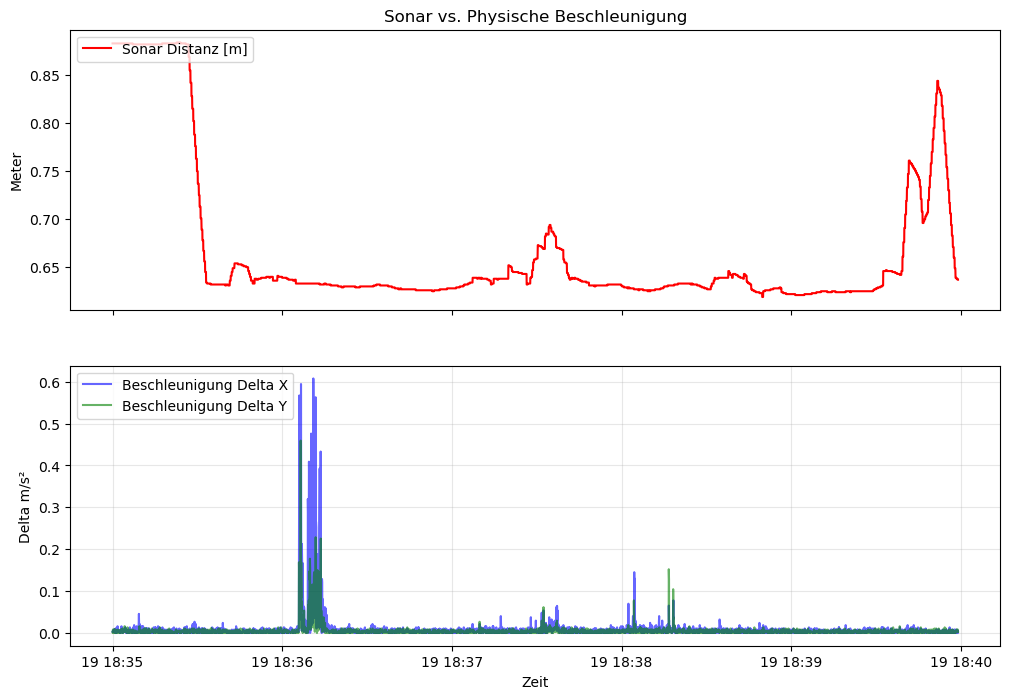

Korrelation Sonar-Sprung zu Bewegung X: -0.0185


In [34]:
import matplotlib.pyplot as plt

# 1. Wir berechnen die Differenz zum vorherigen Wert (Delta)
# Wenn Delta fast 0 ist, hat sich nichts bewegt.
df_test['sonar_delta'] = df_test['sonar_dist'].diff().abs()
df_test['accel_x_delta'] = df_test['accel_x'].diff().abs()
df_test['accel_y_delta'] = df_test['accel_y'].diff().abs()

# 2. Visualisierung: Sonar-Sprünge vs. Beschleunigung
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Sonar Distanz
ax1.plot(df_test['timestamp'], df_test['sonar_dist'], color='red', label='Sonar Distanz [m]')
ax1.set_ylabel('Meter')
ax1.legend(loc='upper left')
ax1.set_title('Sonar vs. Physische Beschleunigung')
plt.xlabel('Zeit')

# Plot 2: Beschleunigung X und Y
ax2.plot(df_test['timestamp'], df_test['accel_x_delta'], color='blue', alpha=0.6, label='Beschleunigung Delta X')
ax2.plot(df_test['timestamp'], df_test['accel_y_delta'], color='green', alpha=0.6, label='Beschleunigung Delta Y')
ax2.set_ylabel('Delta m/s²')
ax2.legend(loc='upper left')

plt.xlabel('Zeit')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Statistik: Korrelation berechnen
corr_x = df_test['sonar_delta'].corr(df_test['accel_x_delta'])
print(f"Korrelation Sonar-Sprung zu Bewegung X: {corr_x:.4f}")

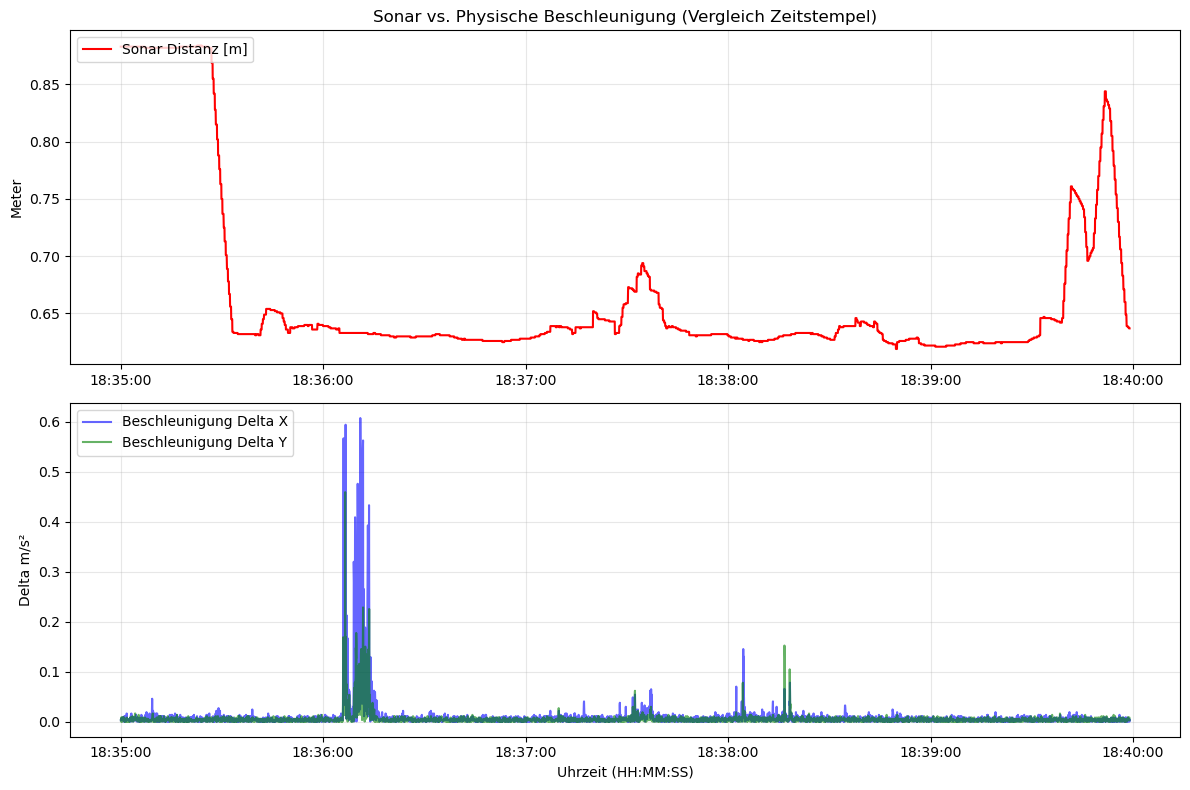

Korrelation Sonar-Sprung zu Bewegung X: -0.0185


In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Visualisierung: Sonar-Sprünge vs. Beschleunigung
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Formatierung der Zeitachse (HH:MM:SS)
time_format = mdates.DateFormatter('%H:%M:%S')

# --- Plot 1: Sonar Distanz ---
ax1.plot(df_test['timestamp'], df_test['sonar_dist'], color='red', label='Sonar Distanz [m]')
ax1.set_ylabel('Meter')
ax1.set_title('Sonar vs. Physische Beschleunigung (Vergleich Zeitstempel)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
# Zeitachse für den oberen Plot sichtbar machen
ax1.xaxis.set_major_formatter(time_format)
ax1.tick_params(labelbottom=True) # Erzwingt die Zeit-Labels auch oben

# --- Plot 2: Beschleunigung Delta X und Y ---
ax2.plot(df_test['timestamp'], df_test['accel_x_delta'], color='blue', alpha=0.6, label='Beschleunigung Delta X')
ax2.plot(df_test['timestamp'], df_test['accel_y_delta'], color='green', alpha=0.6, label='Beschleunigung Delta Y')
ax2.set_ylabel('Delta m/s²')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(time_format)

# Beschriftung ganz unten
plt.xlabel('Uhrzeit (HH:MM:SS)')
fig.tight_layout()
plt.show()

# Statistik: Korrelation berechnen
corr_x = df_test['sonar_delta'].corr(df_test['accel_x_delta'])
print(f"Korrelation Sonar-Sprung zu Bewegung X: {corr_x:.4f}")

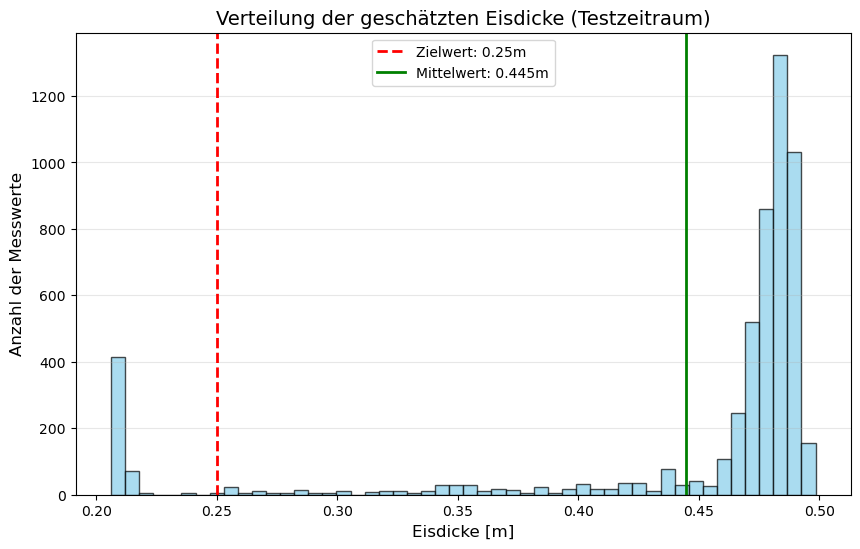

Gesamtanzahl Messwerte: 5383
Durchschnitt: 0.4445 m
Messwerte außerhalb +/- 5cm vom Ziel: 4805 (89.3%)


In [29]:
import matplotlib.pyplot as plt

# 1. Plot erstellen
plt.figure(figsize=(10, 6))

# 2. Histogramm zeichnen
# bins=50 teilt die Daten in 50 Balken auf
n, bins, patches = plt.hist(df_test['ice_thickness'].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# 3. Referenzlinie für die echte Eisdicke (0.25m)
plt.axvline(0.25, color='red', linestyle='dashed', linewidth=2, label='Zielwert: 0.25m')

# 4. Durchschnittliche Messung einzeichnen
mean_val = df_test['ice_thickness'].mean()
plt.axvline(mean_val, color='green', linestyle='-', linewidth=2, label=f'Mittelwert: {mean_val:.3f}m')

# 5. Beschriftung
plt.title('Verteilung der geschätzten Eisdicke (Testzeitraum)', fontsize=14)
plt.xlabel('Eisdicke [m]', fontsize=12)
plt.ylabel('Anzahl der Messwerte', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# 6. Statistik-Ausgabe
total_counts = len(df_test['ice_thickness'].dropna())
out_of_range = len(df_test[abs(df_test['ice_thickness'] - 0.25) > 0.05]) # Werte mit mehr als 5cm Abweichung

print(f"Gesamtanzahl Messwerte: {total_counts}")
print(f"Durchschnitt: {mean_val:.4f} m")
print(f"Messwerte außerhalb +/- 5cm vom Ziel: {out_of_range} ({(out_of_range/total_counts)*100:.1f}%)")

In [25]:
# Filtern auf genau dein Testfenster (18:35 - 18:39)
start_test = "2026-03-19 18:35:00"
end_test   = "2026-03-19 18:40:00"

# Nur die wichtigsten Spalten behalten
df_debug = df_test[['timestamp', 'pressure', 'sonar_dist', 'ice_thickness']]

# Speichern als neue CSV zum Anschauen
df_debug.to_csv("5min_pressure_sonar.csv", index=False)
print("Debug-Datei '5min_pressure_sonar.csv' wurde erstellt.")

Debug-Datei '5min_pressure_sonar.csv' wurde erstellt.


In [26]:
# Charger le fichier
df_5min = pd.read_csv("5min_pressure_sonar.csv")

# 1. Timestamp in echtes Datum/Uhrzeit umwandeln
df_5min['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Index zurücksetzen, damit es bei 0 anfängt
df_test = df_5min.reset_index(drop=True)

df_test.head(50)

,timestamp,pressure,sonar_dist,ice_thickness
0,2026-03-19 18:33:41.020017147,106959.997559,0.883,0.211685
1,2026-03-19 18:33:41.089797497,106959.997559,0.883,0.211685
2,2026-03-19 18:33:41.135697365,106959.997559,0.883,0.211685
3,2026-03-19 18:33:41.219658613,106909.997559,0.883,0.206127
4,2026-03-19 18:33:41.261905432,106909.997559,0.883,0.206127
5,2026-03-19 18:33:41.306195498,106909.997559,0.883,0.206127
6,2026-03-19 18:33:41.349737406,106909.997559,0.883,0.206127
7,2026-03-19 18:33:41.433465242,106909.997559,0.883,0.206127
8,2026-03-19 18:33:41.478061199,106909.997559,0.883,0.206127
9,2026-03-19 18:33:41.520796299,106909.997559,0.883,0.206127
